# Oxford Flowers 102 — Transfer Learning (v3, improved)
MobileNetV2 vs ResNet50V2 | Two-phase training | Contest submission

**Changes from v1 (see ANALYSIS_AND_RECOMMENDATIONS.md):**
1. BatchNorm layers kept **frozen** during fine-tuning (fixes the accuracy crash).
2. Unfreeze more backbone layers (40 MobileNet / 50 ResNet) with a higher fine-tune LR (1e-4).
3. Stronger augmentation + regularized head (BatchNorm, 2x Dropout, L2).
4. `ReduceLROnPlateau` + monitor `val_loss` (more stable than val_accuracy).

## 1. Install & Import

In [12]:
!pip install -q tensorflow-datasets
! pip install -q  tensorflow
import tensorflow as tf
import tensorflow_datasets as tfds
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import os

os.makedirs('outputs', exist_ok=True)
print('TF:', tf.__version__)
print('GPU:', tf.config.list_physical_devices('GPU'))

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 138.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 125.5 MB/s eta 0:00:00


/usr/local/lib/python3.12/dist-packages/jax/_src/cloud_tpu_init.py:86: UserWarning: Transparent hugepages are not enabled. TPU runtime startup and shutdown time should be significantly improved on TPU v5e and newer. If not already set, you may need to enable transparent hugepages in your VM image (sudo sh -c "echo always > /sys/kernel/mm/transparent_hugepage/enabled")
  warnings.warn(


TF: 2.21.0
GPU: []


## 2. Load Dataset

In [13]:
(ds_train, ds_val,ds_test), info = tfds.load(
    'oxford_flowers102',
    split=['train', 'validation', 'test'],
    as_supervised=True,
    with_info=True
)

NUM_CLASSES = 102
IMG_SIZE    = 224
BATCH_SIZE  = 32*2 # we multiply by 2 to make it compatible with new set size doable train and val set 2040

print('Train:', info.splits['train'].num_examples)
print('Val:  ', info.splits['validation'].num_examples)
print('Test: ', info.splits['test'].num_examples)


Dl Completed...: 0 url [00:00, ? url/s]

Dl Size...: 0 MiB [00:00, ? MiB/s]

Extraction completed...: 0 file [00:00, ? file/s]

Generating splits...:   0%|          | 0/3 [00:00<?, ? splits/s]

Generating train examples...: 0 examples [00:00, ? examples/s]

...

Generating test examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.D75RCQ_2.1.1/oxford_flowers102-test.tfrecord-…

Generating validation examples...: 0 examples [00:00, ? examples/s]

Shuffling /root/tensorflow_datasets/oxford_flowers102/incomplete.D75RCQ_2.1.1/oxford_flowers102-validation.tfr…

Dataset oxford_flowers102 downloaded and prepared to /root/tensorflow_datasets/oxford_flowers102/2.1.1. Subsequent calls will reuse this data.
Train: 1020
Val:   1020
Test:  6149


## data Analysis

In [14]:
info

tfds.core.DatasetInfo(
    name='oxford_flowers102',
    full_name='oxford_flowers102/2.1.1',
    description="""
    The Oxford Flowers 102 dataset is a consistent of 102 flower categories commonly
    occurring in the United Kingdom. Each class consists of between 40 and 258
    images. The images have large scale, pose and light variations. In addition,
    there are categories that have large variations within the category and several
    very similar categories.
    
    The dataset is divided into a training set, a validation set and a test set. The
    training set and validation set each consist of 10 images per class (totalling
    1020 images each). The test set consists of the remaining 6149 images (minimum
    20 per class).
    
    Note: The dataset by default comes with a test size larger than the train size.
    For more info see this
    [issue](https://github.com/tensorflow/datasets/issues/3022).
    """,
    homepage='https://www.robots.ox.ac.uk/~vgg/data/flowers/102

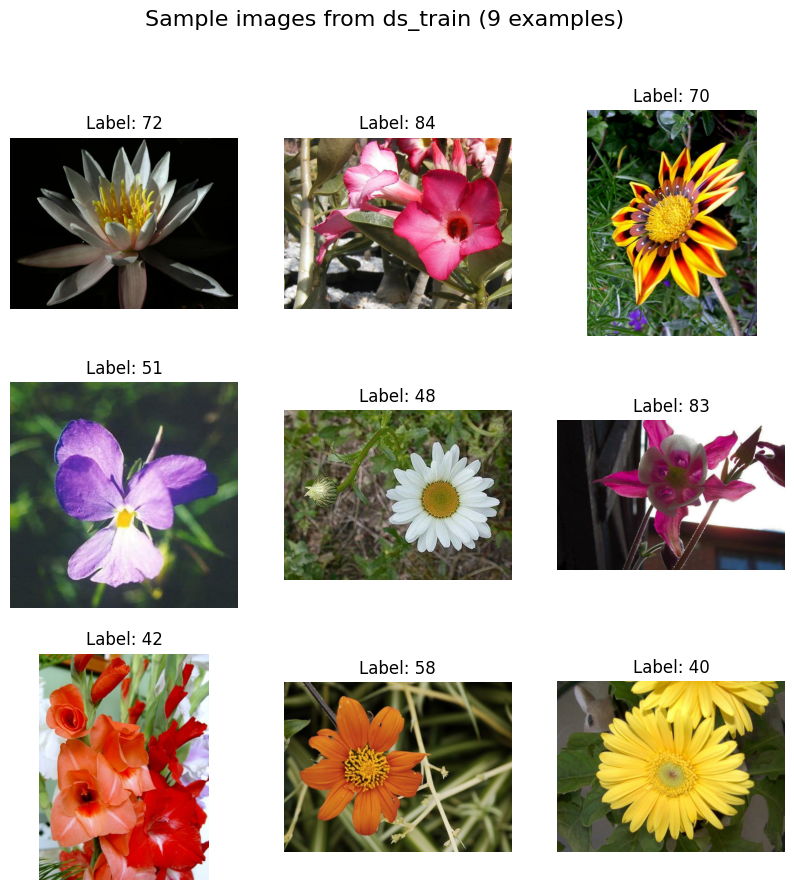

In [15]:
import matplotlib.pyplot as plt

# Take a few examples from ds_train to visualize
num_images_to_show = 9
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(ds_train.take( num_images_to_show)):
    ax = plt.subplot(3, 3, i + 1)
    # Images from tfds.load are typically tf.uint8, matplotlib can display them directly
    plt.imshow(image.numpy())
    plt.title(f"Label: {label.numpy()}")
    plt.axis("off")
plt.suptitle(f"Sample images from ds_train ({num_images_to_show} examples)", fontsize=16)
plt.show()

### tf.data.Dataset
Think of a  not as a static container holding your images, but as an 'ETL' (Extract, Transform, Load) data pipeline built specifically for machine learning.

### ds_train.take(1)
- extract/take  one element from data dataset object as dataset object

### how tensor flow handle dataset object
- Lazy Evaluation (Streaming)When you create a tf.data.Dataset, TensorFlow does not immediately load your data into memory. Instead, it creates a graph of operations (blueprint) ,a set of instructions on how to fetch and modify the data.
**example**
`<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>`
#### What is the element_spec?
- When you print a dataset object, you see the element_spec. This isn't the data itself; it is the blueprint of what the dataset promises to hand you when you ask for data. For a supervised image dataset with a batch size of 32, the blueprint looks like this:
Tuple( TensorSpec(shape=(32, 256, 256, 3)), TensorSpec(shape=(32,)) )


### The Magic of prefetch
The most important feature of a tf.data.Dataset for performance is .prefetch().

Without prefetching, the CPU reads and prepares Batch 1, then the GPU trains on Batch 1. While the GPU is training, the CPU is idle. While the CPU prepares Batch 2, the GPU is idle.

When you add .prefetch(tf.data.AUTOTUNE) to the end of your dataset, it runs the CPU and GPU in parallel. While the GPU is crunching the numbers for Batch 1, the CPU is already in the background fetching, resizing, and preparing Batch 2. The AUTOTUNE flag tells TensorFlow to automatically figure out how many batches it should prepare in advance based on your system's available resources.

`The AUTOTUNE flag just means you are letting TensorFlow decide exactly how many batches to prepare in advance based on how much RAM and CPU power your specific computer has.`

```
 A standard, highly optimized tf.data pipeline
ds_train = (
    raw_dataset
    .shuffle(buffer_size=1000)      # 1. Randomize the data
    .map(process_image,             # 2. Transform (decode, resize, normalize)
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(32)                      # 3. Group into batches of 32 images
    .prefetch(tf.data.AUTOTUNE)     # 4. Optimize hardware utilization
)
```

In [16]:
for image_tensor, label_tensor in ds_train.take(1):
    print("Type of image_tensor:", type(image_tensor))
    print("Shape of image_tensor:", image_tensor.shape)
    print("Dtype of image_tensor:", image_tensor.dtype)
    print("Label tensor:", label_tensor.numpy())
# ds_train.take(1) extract/take  one element from data dataset object as dataset object if you print i just show blueprint (Lazy Evaluation (Streaming)When you create a tf.data.Dataset, TensorFlow does not immediately load your data into memory. Instead, it creates a graph of operations )
image_tensor = next(iter(ds_train.take(1)))
#nex :Return the next item from the iterator. It forces the TensorFlow pipeline to do the work—fetching the images from disk, resizing them, grouping them into a batch—and hands that batch directly to you.
print(type(image_tensor),image_tensor)
print(ds_train.take(1))

Type of image_tensor: <class 'tensorflow.python.framework.ops.EagerTensor'>
Shape of image_tensor: (500, 667, 3)
Dtype of image_tensor: <dtype: 'uint8'>
Label tensor: 72
<class 'tuple'> (<tf.Tensor: shape=(500, 667, 3), dtype=uint8, numpy=
array([[[1, 2, 0],
        [1, 2, 0],
        [1, 2, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[1, 2, 0],
        [1, 2, 0],
        [1, 2, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       [[1, 2, 0],
        [1, 2, 0],
        [1, 2, 0],
        ...,
        [1, 1, 1],
        [1, 1, 1],
        [1, 1, 1]],

       ...,

       [[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        ...,
        [6, 7, 2],
        [6, 7, 2],
        [5, 6, 1]],

       [[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        ...,
        [6, 7, 2],
        [6, 7, 2],
        [5, 6, 1]],

       [[1, 1, 1],
        [1, 1, 1],
        [1, 1, 1],
        ...,
        [6, 7, 2],
        [6, 7

## custom splits strategy
This section merges the training and validation datasets, then re-splits them into an 80/20 ratio. This strategy is employed to increase the effective size of the training dataset.


In [17]:
# This section merges the training and validation datasets, then re-splits them into an 80/20 ratio. This strategy is employed to increase the effective size of the training dataset.
combined_ds = ds_train.concatenate(ds_val)
print('number of sample in combined_ds: ',combined_ds.cardinality().numpy())
num_examples = info.splits['train'].num_examples + info.splits['validation'].num_examples
train_size = int(0.8 * num_examples)

# Initial assignment: Does train_ds become a reference or a copy of combined_ds?
temp_train_ds_assignment_check = combined_ds
print(f"\n--- Checking initial assignment (temp_train_ds_assignment_check = combined_ds) ---")
print(f"Are combined_ds and temp_train_ds_assignment_check the exact same object (using 'is')? {combined_ds is temp_train_ds_assignment_check}")
print(f"ID of combined_ds: {id(combined_ds)}")
print(f"ID of temp_train_ds_assignment_check: {id(temp_train_ds_assignment_check)}")

# Now, let's apply the actual split logic for train_ds and val_ds
# These operations (take and skip) create *new* dataset objects.
train_ds = combined_ds.take(train_size)
val_ds = combined_ds.skip(train_size)

print(f"\n--- Checking after splitting (train_ds = combined_ds.take(train_size)) ---")
print(f"Are combined_ds and train_ds the exact same object (using 'is')? {combined_ds is train_ds}")
print(f"ID of combined_ds: {id(combined_ds)}")
print(f"ID of train_ds (after take): {id(train_ds)}")
print(f"ID of val_ds (after skip): {id(val_ds)}")


print(f"\nNew combined training set size: {train_ds.cardinality().numpy()} examples")
print(f"New combined validation set size: {val_ds.cardinality().numpy()} examples")

number of sample in combined_ds:  2040

--- Checking initial assignment (temp_train_ds_assignment_check = combined_ds) ---
Are combined_ds and temp_train_ds_assignment_check the exact same object (using 'is')? True
ID of combined_ds: 139235737187392
ID of temp_train_ds_assignment_check: 139235737187392

--- Checking after splitting (train_ds = combined_ds.take(train_size)) ---
Are combined_ds and train_ds the exact same object (using 'is')? False
ID of combined_ds: 139235737187392
ID of train_ds (after take): 139235091840992
ID of val_ds (after skip): 139235091831248

New combined training set size: 1632 examples
New combined validation set size: 408 examples


In [18]:
ds_train_combined = combined_ds.take(combined_ds.cardinality().numpy()) # take func is create new dataset
print('is train_ds equal to combined object address / is reference ', {train_ds is combined_ds})
print(f"ID of combined_ds: {id(combined_ds)}")
print(f"ID of train_ds (after take): {id(train_ds)}")
print('number of sample in ds_train_combined: ',ds_train_combined.cardinality().numpy())

is train_ds equal to combined object address / is reference  {False}
ID of combined_ds: 139235737187392
ID of train_ds (after take): 139235091840992
number of sample in ds_train_combined:  2040


In [19]:

#check number of smaple per class
import collections as coll
# 1. Create an empty counter to keep track of the totals
class_collections_label_count = coll.Counter()
for img_tensor ,lable_tens in ds_test :
  lable=lable_tens.numpy().flatten()
  #print(lable)
  class_collections_label_count.update(lable)
print('number of sample per class ' , class_collections_label_count)

print('number of test ds sample: ',ds_test.cardinality().numpy())
# print('show test sample:', next(iter(ds_test.take(1))))
# filter_lst = (i,ds_test.filter(lambda img , labelTR : labelTR == i, 'f' ) for i in range(1,103) )

number of sample per class  Counter({np.int64(50): 238, np.int64(76): 231, np.int64(45): 176, np.int64(72): 174, np.int64(88): 164, np.int64(73): 151, np.int64(80): 146, np.int64(93): 142, np.int64(87): 134, np.int64(77): 117, np.int64(82): 111, np.int64(42): 110, np.int64(94): 108, np.int64(40): 107, np.int64(74): 100, np.int64(57): 94, np.int64(81): 92, np.int64(59): 89, np.int64(55): 89, np.int64(36): 88, np.int64(75): 87, np.int64(79): 85, np.int64(64): 82, np.int64(71): 76, np.int64(52): 73, np.int64(43): 73, np.int64(49): 72, np.int64(95): 71, np.int64(22): 71, np.int64(10): 67, np.int64(11): 67, np.int64(83): 66, np.int64(51): 65, np.int64(16): 65, np.int64(29): 65, np.int64(7): 65, np.int64(89): 62, np.int64(97): 62, np.int64(17): 62, np.int64(70): 58, np.int64(28): 58, np.int64(90): 56, np.int64(35): 55, np.int64(47): 51, np.int64(54): 51, np.int64(46): 47, np.int64(39): 47, np.int64(56): 47, np.int64(58): 47, np.int64(91): 46, np.int64(96): 46, np.int64(27): 46, np.int64(4): 

In [20]:
#check missing classes

# Convert dict_keys to a list, then to an array
np_classes = np.array(list(class_collections_label_count.keys()))

# Create your expected range as an array
expected_range = np.arange(1, 103)

# Check if ALL elements in np_classes exist inside expected_range
is_valid = np.isin(np_classes, expected_range)

print("Are all classes valid?", is_valid)
print('index of missing class:[] ' , np.where(is_valid == False))
print('missing_classes: ',np_classes[np.where(is_valid == False)])
# for i in range(1,103):
#   print('missing_classes by for ',i) if i not in np_classes else None
print (len(class_collections_label_count.keys()))
print (class_collections_label_count[39])
print (class_collections_label_count.get(102))

Are all classes valid? [ True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True False  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True  True  True  True  True  True  True
  True  True  True  True  True  True]
index of missing class:[]  (array([39]),)
missing_classes:  [0]
102
47
None


In [21]:

expected_classes = np.arange(1, 103)
actual_classes = np.array(list(class_collections_label_count.keys()))

# Find what is in 'expected' but NOT in 'actual'
missing_classes = np.setdiff1d(expected_classes, actual_classes)

if missing_classes.size > 0:
    print(f"Warning! You are missing these classes: {missing_classes}")
else:
    print("All 102 classes are present!")

Warning! You are missing these classes: [102]


### Approach 1 (extracting images from the dataset and appending them to Python lists)
is functionally dangerous for two main reasons:

The RAM Crash (Out of Memory): TensorFlow datasets are designed to stream data lazily from your hard drive, keeping your memory clear. Pulling thousands of raw, uncompressed image tensors out of that pipeline and dumping them into standard Python lists forces your computer to hold the entire dataset in RAM simultaneously. For image data, this will almost always crash your system.

The Slicing Trap (Strict Dimensions): When you attempt to push those Python lists back into tf.data.Dataset.from_tensor_slices(), TensorFlow tries to stack every image into one massive, rigid mathematical box. If even a single image has a slightly different height or width, the stack collapses and instantly throws a ValueError.

In [ ]:
# # Extract 2040 samples from ds_test to create a validation dataset (ds_val), and then update ds_test to prevent data leakage.
# # by 20 smaple per class in total 1040 for all classes
# from  collections import Counter
# # unbatch for test ds this need for implement ds as element wase one by one when work with take func one image at time but for batch ds take one batch at time from exta batch dimensions.
# print(BATCH_SIZE)
# tf.data.experimental.cardinality(ds_test).numpy() # if it 6149 that mean this ds isnot batch ds where it base all samples

# # Initialize containers
# val_images = []
# val_labels = []
# new_test_images = []
# new_test_labels = []
# # Tracker for how many images we've grabbed for each class
# unbatch_ds = ds_test #where da_test is already effectively unbatched not need .unbatch()
# class_counts = Counter()
# SAMPLES_PER_CLASS = 20
# print("Extracting validation samples...")
# for image, label in unbatch_ds:
#   image = tf.image.resize(image, [IMG_SIZE, IMG_SIZE])# this for make this code work with tf.data.Dataset.from_tensor_slices must be box shape where all dimension is same
#   image_ = image.numpy()
#   label_ = label.numpy().flatten()

#   label_lst = label_.tolist()
#   print(image.shape, label_)
#   if class_counts[int(label_)] < SAMPLES_PER_CLASS:
#     val_images.append(image)
#     val_labels.append(label)
#     class_counts.update(label_lst)
#   else:
#     new_test_images.append(image)
#     new_test_labels.append(label)
# print("Done extracting validation samples.")
# print(val_images[0].shape)
# print(f"Extraction complete. Validation samples: {len(val_labels)}")
# print(f"Remaining Test samples: {len(new_test_labels)}")
# ds_val = tf.data.Dataset.from_tensor_slices((val_images, val_labels))
# ds_test_updated = tf.data.Dataset.from_tensor_slices((new_test_images, new_test_labels))


### Approach Two (The Boolean Mask Method)

the pure TensorFlow solution we used to replace the Python lists—here is exactly how it solves the problems:

It acts like a bouncer, not a warehouse (Fixes the RAM Crash): Instead of hoarding thousands of images in your computer's memory, the Boolean mask just hands TensorFlow a simple clipboard of "True/False" VIP rules. TensorFlow keeps the heavy images safely on the hard drive and just checks the clipboard as the images stream by one at a time.

It filters instead of packing (Fixes the Slicing Trap): from_tensor_slices tries to forcefully pack all your images into a single, perfectly uniform mathematical box (which is why they crash if they aren't resized). Using .filter() avoids this completely. It just acts as a fork in the road on the data pipeline, sending Validation images left and Test images right, without ever caring about their heights or widths.

(If you instead meant you wanted more details on the "Slicing Trap" from the previous message: Think of from_tensor_slices like an ice cube tray. Every single slot must be the exact same dimension. If even one image is a different size, the tray shatters.)

In [22]:
import tensorflow as tf
from collections import Counter

print("Pass 1: Scanning labels to determine split (Fast, low memory)...")

is_val_mask = []
class_counts = Counter()
SAMPLES_PER_CLASS = 20

# .map() tells TensorFlow: "Only give me the labels. Keep the images on the hard drive/in the pipeline."
for label in ds_test.map(lambda img, lbl: lbl):
    lbl_val = int(label.numpy())

    if class_counts[lbl_val] < SAMPLES_PER_CLASS:
        is_val_mask.append(True)  # Tag this item for the Validation set
        class_counts[lbl_val] += 1
    else:
        is_val_mask.append(False) # Tag this item for the updated Test set

print(f"Done. Identified {sum(is_val_mask)} validation samples out of {len(is_val_mask)} total.")

# ---------------------------------------------------------
# Pass 2: Rebuild the datasets natively
# ---------------------------------------------------------

# Convert our Python True/False list into a lightning-fast TensorFlow constant
tf_mask = tf.constant(is_val_mask, dtype=tf.bool)

# .enumerate() adds an ID number (0, 1, 2...) to every image as it passes through the pipeline
ds_enumerated = ds_test.enumerate()

# Define pure TensorFlow filters
def filter_val(index, elements):
    return tf_mask[index] # Keep it if the mask is True

def filter_test(index, elements):
    return tf.math.logical_not(tf_mask[index]) # Keep it if the mask is False

print("Rebuilding pipelines...")

# 1. Enumerate -> 2. Filter using our mask -> 3. Strip the ID number away so we just have (image, label)
ds_val_combined = (
    ds_enumerated
    .filter(filter_val)
    .map(lambda idx, elements: elements, num_parallel_calls=tf.data.AUTOTUNE)
)

ds_test_updated = (
    ds_enumerated
    .filter(filter_test)
    .map(lambda idx, elements: elements, num_parallel_calls=tf.data.AUTOTUNE)
)

print("Datasets successfully split natively! No RAM bloat, no resizing needed.")

Pass 1: Scanning labels to determine split (Fast, low memory)...
Done. Identified 2040 validation samples out of 6149 total.
Rebuilding pipelines...
Datasets successfully split natively! No RAM bloat, no resizing needed.


In [23]:
# show single sample
print(list(ds_test_updated.take(1).as_numpy_iterator()))
print(list(ds_val.take(1).as_numpy_iterator()))


[(array([[[ 94, 139,  48],
        [ 90, 135,  44],
        [ 87, 130,  38],
        ...,
        [ 71,  55,  32],
        [ 64,  50,  24],
        [ 58,  44,  17]],

       [[ 92, 137,  46],
        [ 89, 134,  41],
        [ 87, 130,  38],
        ...,
        [ 67,  51,  28],
        [ 62,  46,  21],
        [ 55,  41,  15]],

       [[ 89, 132,  40],
        [ 88, 132,  37],
        [ 87, 131,  36],
        ...,
        [ 65,  49,  26],
        [ 60,  44,  21],
        [ 53,  38,  15]],

       ...,

       [[ 39,  49,  24],
        [ 33,  43,  18],
        [ 30,  38,  15],
        ...,
        [ 97, 127,  37],
        [112, 142,  56],
        [126, 155,  75]],

       [[ 35,  45,  20],
        [ 30,  40,  15],
        [ 28,  36,  13],
        ...,
        [ 94, 124,  34],
        [111, 141,  55],
        [129, 158,  78]],

       [[ 32,  42,  17],
        [ 27,  37,  12],
        [ 25,  33,  10],
        ...,
        [ 91, 121,  31],
        [108, 138,  52],
        [124, 153,  73

## 3. Data Pipeline
Stronger augmentation than v1 to fight overfitting (only 10 images/class).

In [24]:
AUTOTUNE = tf.data.AUTOTUNE

augment = tf.keras.Sequential([
    tf.keras.layers.RandomFlip('horizontal'),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.2),
    tf.keras.layers.RandomTranslation(0.1, 0.1),
])

def make_pipeline(ds, preprocess_fn, training=False):
    def prep(img, label):
        img = tf.image.resize(img, [IMG_SIZE, IMG_SIZE])
        img = tf.cast(img, tf.float32)
        img = preprocess_fn(img)
        return img, label

    ds = ds.map(prep, num_parallel_calls=AUTOTUNE)
    if training:
        ds = ds.shuffle(1024)
        ds = ds.map(lambda x, y: (augment(x, training=True), y), num_parallel_calls=AUTOTUNE)
    return ds.batch(BATCH_SIZE).prefetch(AUTOTUNE)

## 4. Build Model (shared function)
Regularized head: BatchNorm + two Dropouts + L2 to reduce the train/val gap.

In [25]:
def build_model(backbone):
    backbone.trainable = False
    inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
    x = backbone(inputs, training=False)
    x = tf.keras.layers.GlobalAveragePooling2D()(x)
    x = tf.keras.layers.BatchNormalization()(x)
    x = tf.keras.layers.Dropout(0.3)(x)
    x = tf.keras.layers.Dense(224, activation='relu',
                              kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
    x = tf.keras.layers.Dropout(0.2)(x)
    x = tf.keras.layers.Dense(224, activation='relu',
                               kernel_regularizer=tf.keras.regularizers.l2(1e-3))(x)
    outputs = tf.keras.layers.Dense(NUM_CLASSES, activation='softmax')(x)
    return tf.keras.Model(inputs, outputs)

## 5. Train & Evaluate (helper)
**Key fix:** during fine-tuning we unfreeze the top layers but keep every BatchNorm layer frozen, so the backbone's running statistics are not corrupted by the tiny batches.

In [26]:
def make_callbacks():
    return [
        tf.keras.callbacks.EarlyStopping(
            monitor='val_loss', patience=6, restore_best_weights=True),
        tf.keras.callbacks.ReduceLROnPlateau(
            monitor='val_loss', factor=0.5, patience=3, min_lr=1e-7),
    ]


def train_and_evaluate(name, backbone, preprocess_fn, train_ds_raw, val_ds_raw,
                       fine_tune_layers=40):
    print(f'\n===============================')
    print(f'  {name}')
    print(f'===============================')

    train_ds = make_pipeline(train_ds_raw, preprocess_fn, training=True)
    val_ds   = make_pipeline(val_ds_raw,   preprocess_fn, training=False)

    model = build_model(backbone)

    # --- Phase 1: train head only (backbone frozen) ---
    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-3),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print('Phase 1: head training...')
    h1 = model.fit(train_ds, validation_data=val_ds, epochs=20,
                   callbacks=make_callbacks())

    # --- Phase 2: fine-tune top layers, KEEP BatchNorm FROZEN ---
    backbone.trainable = True
    for layer in backbone.layers[:-fine_tune_layers]:
        layer.trainable = False
    for layer in backbone.layers:                       # <-- critical fix
        if isinstance(layer, tf.keras.layers.BatchNormalization):
            layer.trainable = False

    model.compile(
        optimizer=tf.keras.optimizers.Adam(1e-4),       # higher than v1's 1e-5
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )
    print('Phase 2: fine-tuning...')
    h2 = model.fit(train_ds, validation_data=val_ds, epochs=20,
                   callbacks=make_callbacks())

    # restore_best_weights already left `model` at its best val_loss point
    model.save(f'outputs/best_{name}.keras')
    best = model

    # --- Metrics on val set ---
    y_true, y_pred = [], []
    for imgs, labels in val_ds:
        preds = best.predict(imgs, verbose=0)
        y_pred.extend(np.argmax(preds, axis=1))
        y_true.extend(labels.numpy())
    y_true, y_pred = np.array(y_true), np.array(y_pred)

    metrics = {
        'accuracy':  accuracy_score(y_true, y_pred),
        'precision': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'recall':    recall_score(y_true, y_pred, average='macro', zero_division=0),
        'f1':        f1_score(y_true, y_pred, average='macro', zero_division=0),
    }
    print(f'\nVal Results for {name}:')
    for k, v in metrics.items():
        print(f'  {k:10s}: {v:.4f}')

    # --- Training curves ---
    acc  = h1.history['accuracy']     + h2.history['accuracy']
    vacc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    split = len(h1.history['accuracy'])

    plt.figure(figsize=(8, 4))
    plt.plot(acc,  label='Train acc')
    plt.plot(vacc, label='Val acc')
    plt.axvline(split, color='gray', linestyle='--', label='Fine-tune start')
    plt.title(f'{name} — Training Accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    plt.tight_layout()
    plt.savefig(f'outputs/curves_{name}.png')
    plt.show()

    return best, metrics, y_true, y_pred

## 6. Train MobileNetV2


  MobileNetV2
Phase 1: head training...
Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 21s 186ms/step - accuracy: 0.3459 - loss: 3.5008 - val_accuracy: 0.3176 - val_loss: 3.5475 - learning_rate: 0.0010
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 18s 179ms/step - accuracy: 0.6016 - loss: 2.0866 - val_accuracy: 0.4657 - val_loss: 2.6426 - learning_rate: 0.0010
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 18s 178ms/step - accuracy: 0.6843 - loss: 1.7538 - val_accuracy: 0.5088 - val_loss: 2.4161 - learning_rate: 0.0010
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 178ms/step - accuracy: 0.7149 - loss: 1.5960 - val_accuracy: 0.5647 - val_loss: 2.2158 - learning_rate: 0.0010
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 18s 178ms/step - accuracy: 0.7422 - loss: 1.5035 - val_accuracy: 0.5902 - val_loss: 2.1141 - learning_rate: 0.0010
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 17s 177ms/step - accuracy: 0.7622 - loss: 1.3960 - val_accuracy: 0.5647 - val_loss: 2.2355 - learning_rate: 0.0010
Epoch 7/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 17s

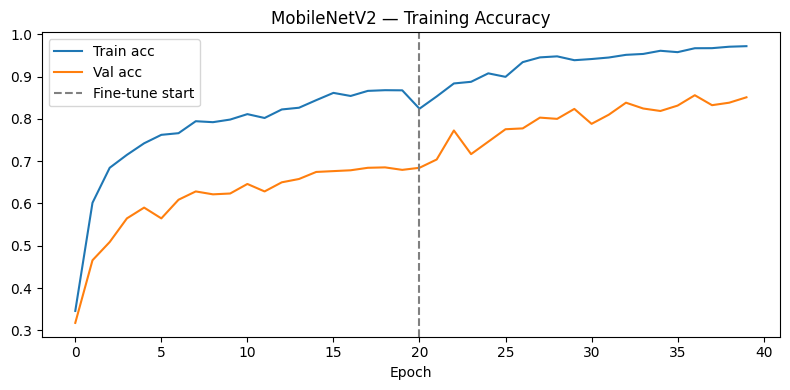

In [28]:
mobilenet_backbone = tf.keras.applications.MobileNetV2(
    include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
mobilenet_preprocess = tf.keras.applications.mobilenet_v2.preprocess_input

model_mobile, metrics_mobile, y_true_mobile, y_pred_mobile = train_and_evaluate(
    'MobileNetV2', mobilenet_backbone, mobilenet_preprocess,ds_test,ds_val, #ds_train_combined, ds_val_combined,
    fine_tune_layers=40
)

## 7. Train ResNet50V2

94668760/94668760 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step

  ResNet50V2
Phase 1: head training...
Epoch 1/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 45s 432ms/step - accuracy: 0.3480 - loss: 3.5238 - val_accuracy: 0.4461 - val_loss: 3.0908 - learning_rate: 0.0010
Epoch 2/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 417ms/step - accuracy: 0.5978 - loss: 2.1371 - val_accuracy: 0.5529 - val_loss: 2.3027 - learning_rate: 0.0010
Epoch 3/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 41s 418ms/step - accuracy: 0.6785 - loss: 1.7735 - val_accuracy: 0.6343 - val_loss: 1.9622 - learning_rate: 0.0010
Epoch 4/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 411ms/step - accuracy: 0.7022 - loss: 1.6485 - val_accuracy: 0.6324 - val_loss: 1.9116 - learning_rate: 0.0010
Epoch 5/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 411ms/step - accuracy: 0.7304 - loss: 1.5290 - val_accuracy: 0.6765 - val_loss: 1.8126 - learning_rate: 0.0010
Epoch 6/20
97/97 ━━━━━━━━━━━━━━━━━━━━ 40s 408ms/step - accuracy: 0.7491 - loss: 1.4667 - val_accuracy: 0.6755 - val_loss: 1.7624 - learning_rate

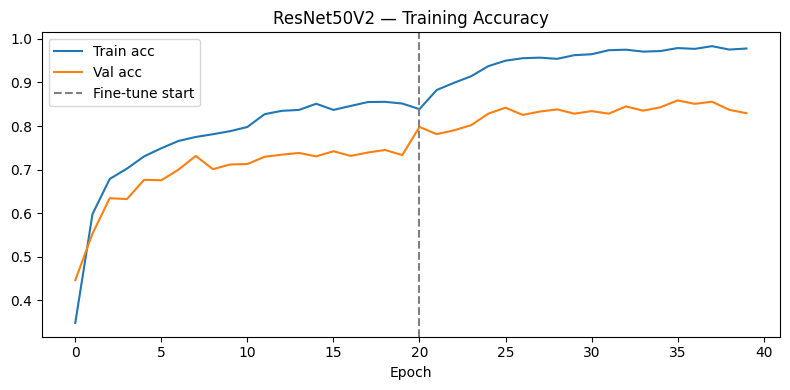

In [29]:
resnet_backbone = tf.keras.applications.ResNet50V2(
    include_top=False, weights='imagenet', input_shape=(IMG_SIZE, IMG_SIZE, 3)
)
resnet_preprocess = tf.keras.applications.resnet_v2.preprocess_input

model_resnet, metrics_resnet, y_true_resnet, y_pred_resnet = train_and_evaluate(
    'ResNet50V2', resnet_backbone, resnet_preprocess,ds_test,ds_val, #ds_train_combined, ds_val_combined,
    fine_tune_layers=50
)

## 8. Compare Models

In [30]:
import pandas as pd

df = pd.DataFrame({
    'MobileNetV2': metrics_mobile,
    'ResNet50V2':  metrics_resnet,
}).T

print('\n=== Model Comparison (Validation) ===')
print(df.to_string())

best_name  = 'ResNet50V2'  if metrics_resnet['f1'] >= metrics_mobile['f1'] else 'MobileNetV2'
best_model = model_resnet  if best_name == 'ResNet50V2' else model_mobile
best_preprocess = resnet_preprocess if best_name == 'ResNet50V2' else mobilenet_preprocess
print(f'\nBest model: {best_name}')


=== Model Comparison (Validation) ===
             accuracy  precision    recall        f1
MobileNetV2  0.855882   0.881667  0.855882  0.849435
ResNet50V2   0.855882   0.889160  0.855882  0.854107

Best model: ResNet50V2


## 9. Confusion Matrix (Best Model — Val Set)

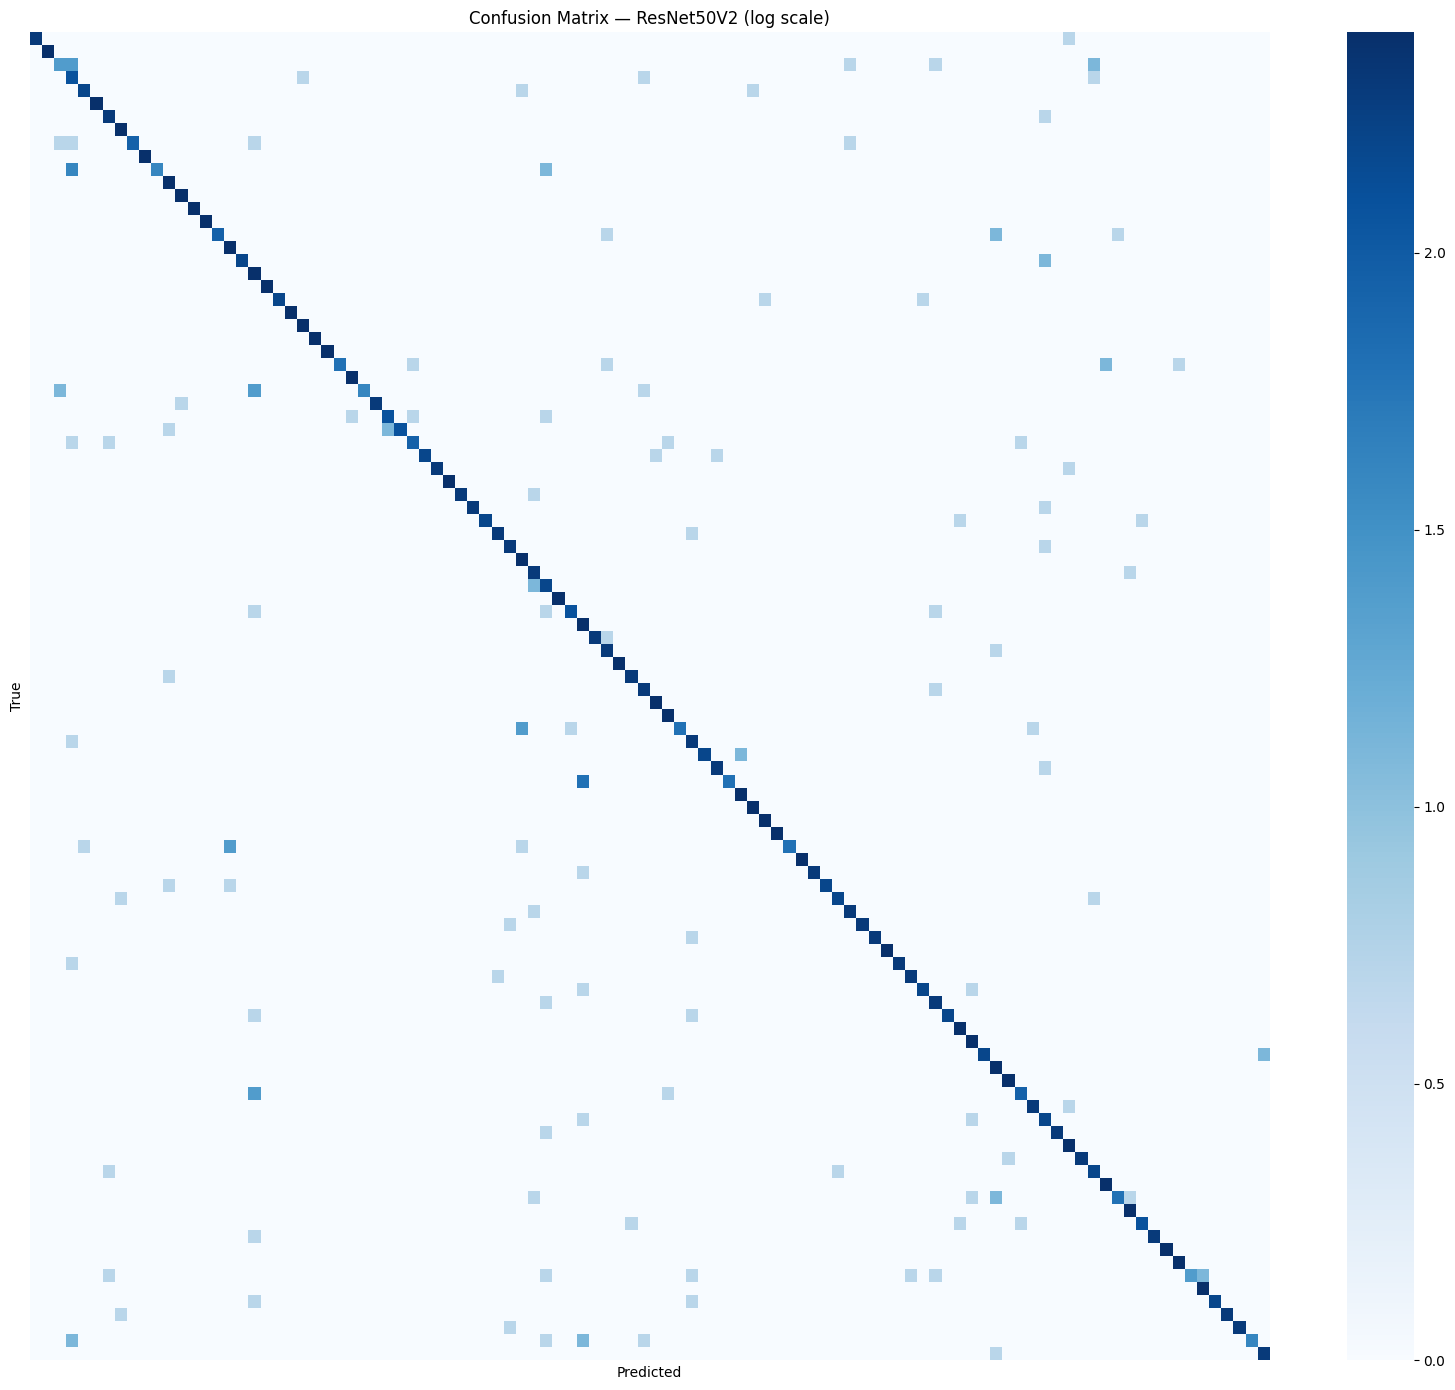

In [39]:
y_true = y_true_resnet if best_name == 'ResNet50V2' else y_true_mobile
y_pred = y_pred_resnet if best_name == 'ResNet50V2' else y_pred_mobile

cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(16, 14))
sns.heatmap(np.log1p(cm), cmap='Blues', xticklabels=False, yticklabels=False)
plt.title(f'Confusion Matrix — {best_name} (log scale)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.savefig(f'outputs/confusion_matrix_{best_name}.png')
plt.show()

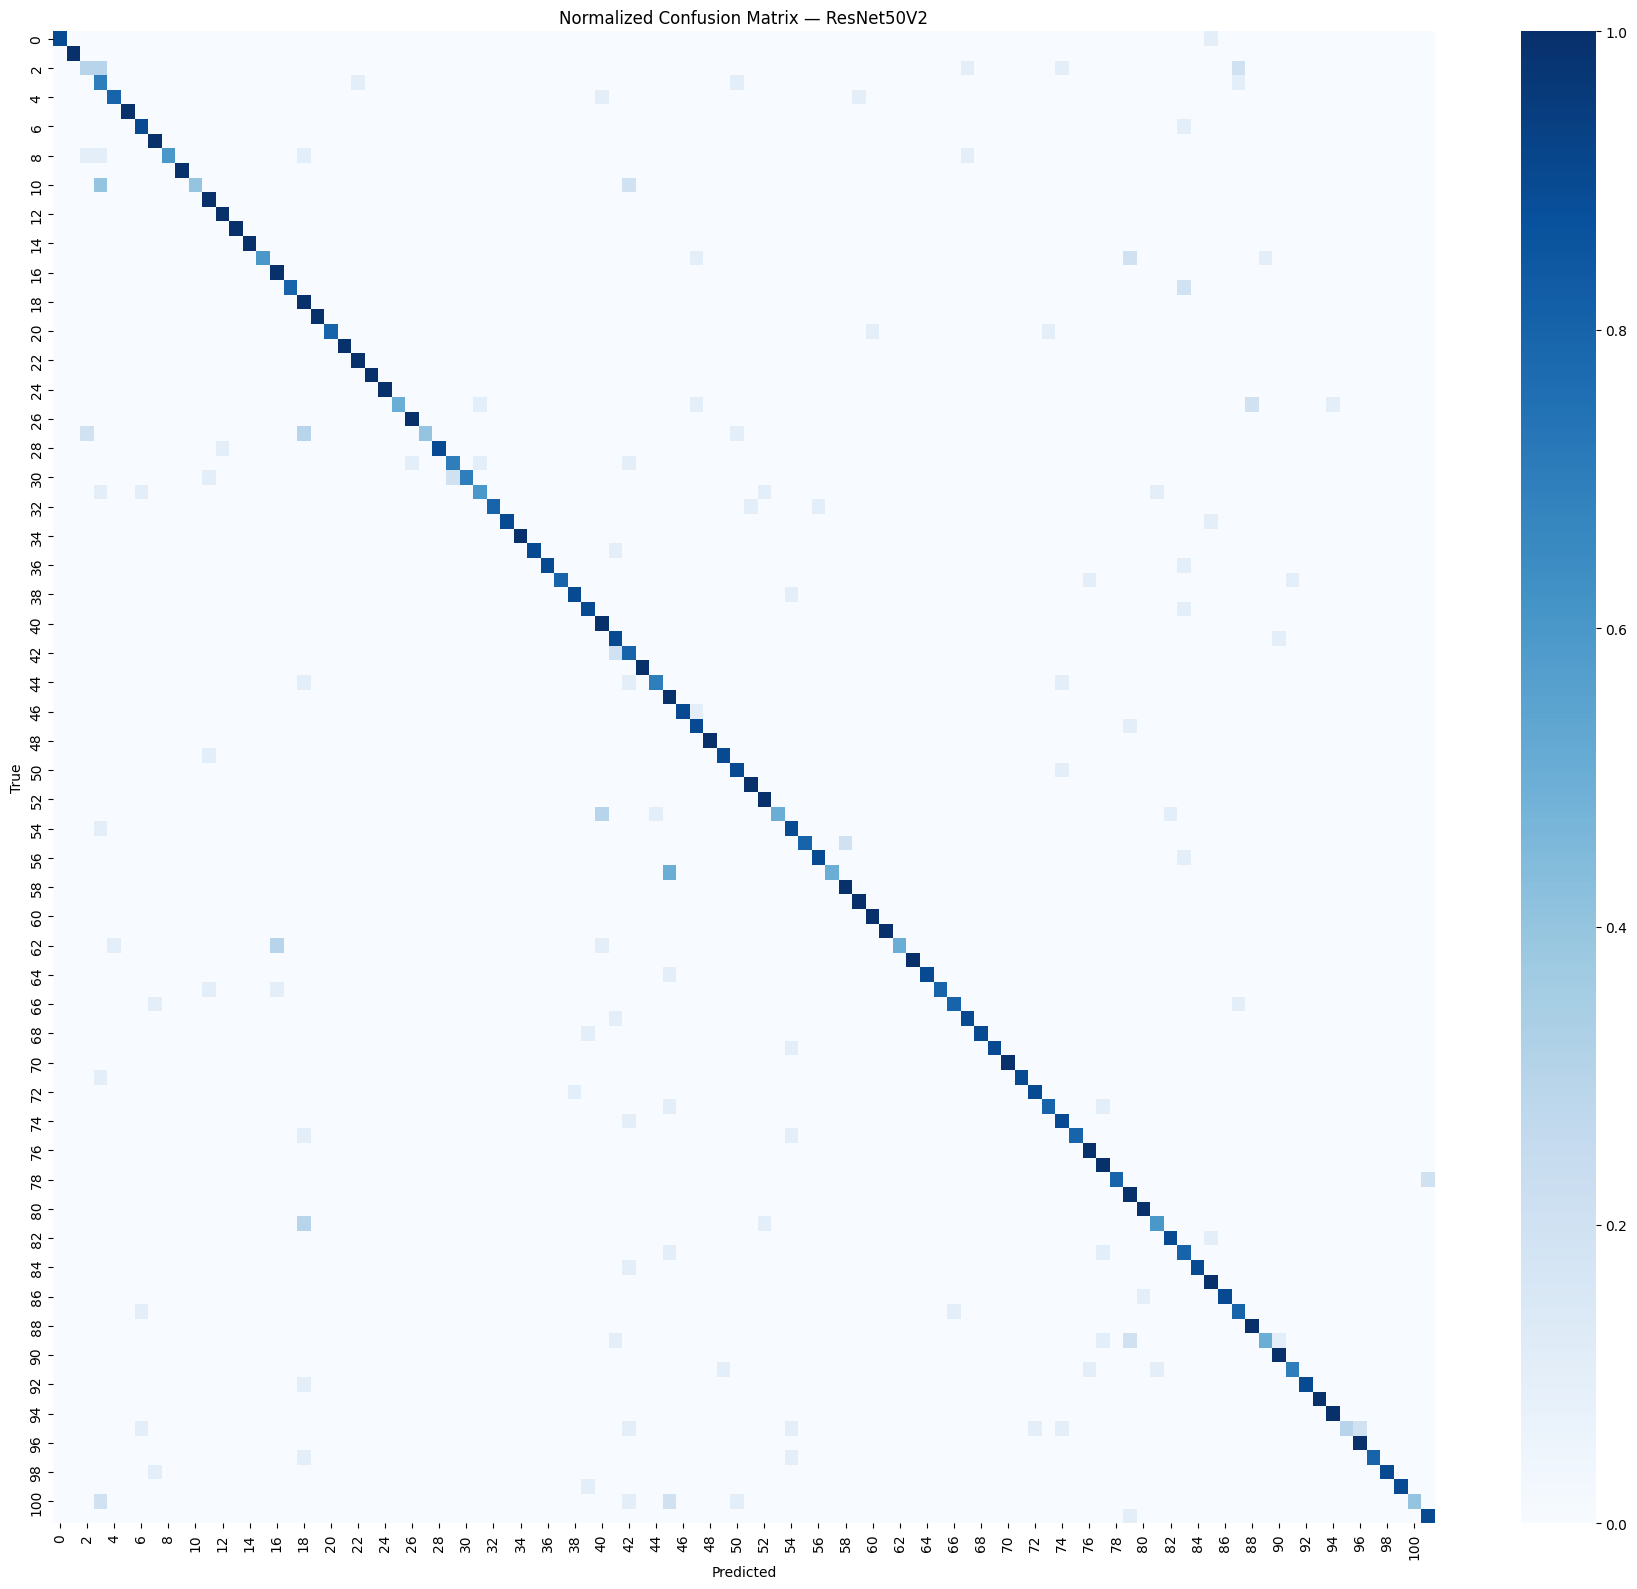

In [40]:
cm_norm = cm.astype("float") / cm.sum(axis=1, keepdims=True)

plt.figure(figsize=(18, 16))

sns.heatmap(
    cm_norm,
    cmap="Blues",
    vmin=0,
    vmax=1
)

plt.title(f"Normalized Confusion Matrix — {best_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

## 10. Final Test Set Evaluation & Predictions

In [33]:
test_ds = make_pipeline(ds_train, best_preprocess, training=False)

y_true_test, y_pred_test = [], []
for imgs, labels in test_ds:
    preds = best_model.predict(imgs, verbose=0)
    y_pred_test.extend(np.argmax(preds, axis=1))
    y_true_test.extend(labels.numpy())
y_true_test = np.array(y_true_test)
y_pred_test = np.array(y_pred_test)

print(f'=== TEST SET — {best_name} ===')
print(f'Accuracy  : {accuracy_score(y_true_test, y_pred_test):.4f}')
print(f'Precision : {precision_score(y_true_test, y_pred_test, average="macro", zero_division=0):.4f}')
print(f'Recall    : {recall_score(y_true_test, y_pred_test, average="macro", zero_division=0):.4f}')
print(f'Macro F1  : {f1_score(y_true_test, y_pred_test, average="macro", zero_division=0):.4f}')

# Save predictions
pd.DataFrame({'predicted': y_pred_test, 'true': y_true_test}).to_csv(
    'outputs/final_predictions.csv', index=False
)
print('\nSaved: outputs/final_predictions.csv')

=== TEST SET — ResNet50V2 ===
Accuracy  : 0.8284
Precision : 0.8662
Recall    : 0.8284
Macro F1  : 0.8268

Saved: outputs/final_predictions.csv


## 11. (Optional) Retrain best model on Train + Validation
The official Flowers102 train split has only **10 images/class**. Merging train+val doubles the
data to ~20/class and is allowed (the **test** set is still untouched). This usually gives the
biggest single jump in contest F1. Run this only after you've picked `best_name` above.

In [ ]:
RUN_COMBINED = False  # set True for the final contest model

if RUN_COMBINED:
    combined_raw = ds_train.concatenate(ds_val)
    if best_name == 'ResNet50V2':
        bb = tf.keras.applications.ResNet50V2(include_top=False, weights='imagenet',
                                              input_shape=(IMG_SIZE, IMG_SIZE, 3))
        prep_fn, ft = resnet_preprocess, 50
    else:
        bb = tf.keras.applications.MobileNetV2(include_top=False, weights='imagenet',
                                               input_shape=(IMG_SIZE, IMG_SIZE, 3))
        prep_fn, ft = mobilenet_preprocess, 40

    # Use the test set only to report final numbers, never to choose weights.
    final_model, _, _, _ = train_and_evaluate(
        f'{best_name}_combined', bb, prep_fn, combined_raw, ds_test, fine_tune_layers=ft
    )
    print('Combined-data model saved as best_' + best_name + '_combined.keras')